In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [5]:
file_path = 'Advanced_Regression_HousePrice_Dataset.csv.csv'


df = pd.read_csv(file_path)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

Dataset Loaded Successfully
Shape: (3800, 12)


# BASIC INFORMATION

In [6]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   str    
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 356.4 KB


In [8]:
df.describe()


,property_id,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
count,3800.00000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3.800000e+03
mean,201900.50000,1716.925526,3.428158,2.916316,6.502237,22.537105,13.085132,0.548421,0.472895,4.242911,2.071940e+07
std,1097.10984,582.996559,1.356682,1.133540,1.766945,12.325740,6.537425,0.497715,0.499330,2.045371,8.707465e+06
min,200001.00000,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.500000,1.506126e+06
25%,200950.75000,1322.000000,2.000000,2.000000,5.300000,14.000000,8.500000,0.000000,0.000000,2.810000,1.446895e+07
50%,201900.50000,1700.500000,3.000000,3.000000,6.500000,20.000000,13.000000,1.000000,0.000000,4.220000,1.989180e+07
75%,202850.25000,2105.000000,4.000000,4.000000,7.700000,29.000000,17.500000,1.000000,1.000000,5.650000,2.596062e+07
max,203800.00000,3776.000000,7.000000,6.000000,10.000000,80.000000,38.700000,1.000000,1.000000,12.000000,5.930315e+07


In [9]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

# DATA VISUALIZATION

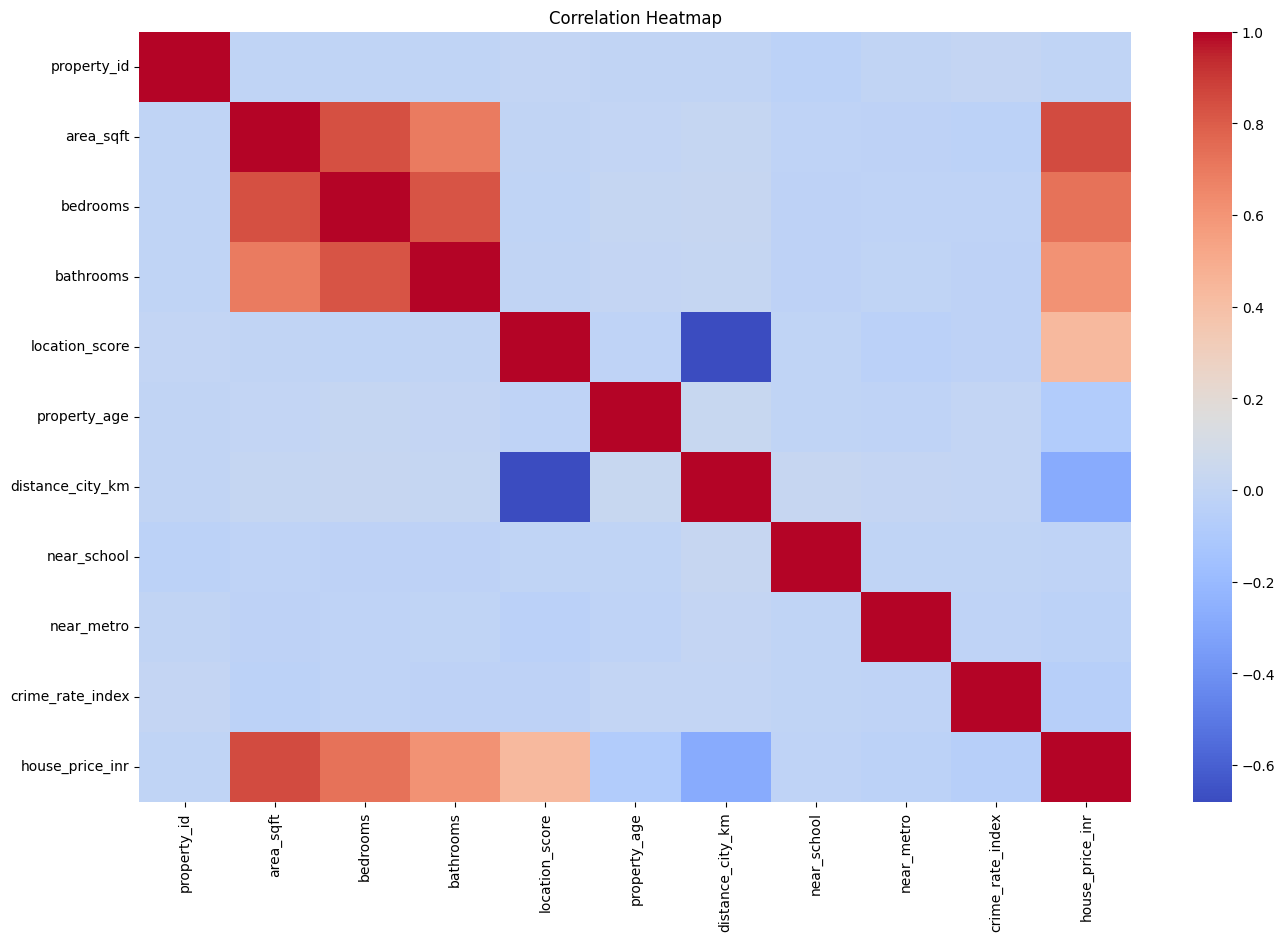

In [10]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()

Target Distribution

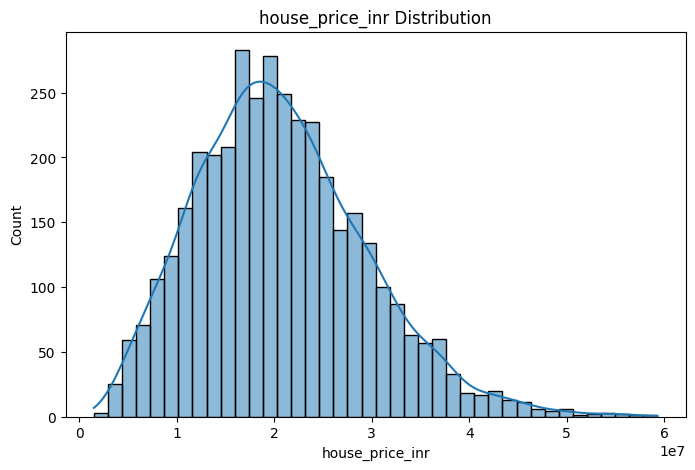

In [11]:
if 'Price' in df.columns:
    target_column = 'Price'
elif 'SalePrice' in df.columns:
    target_column = 'SalePrice'
else:
    target_column = df.columns[-1]

plt.figure(figsize=(8,5))
sns.histplot(df[target_column], kde=True)
plt.title(f'{target_column} Distribution')
plt.show()

Boxplots for Outlier Detection

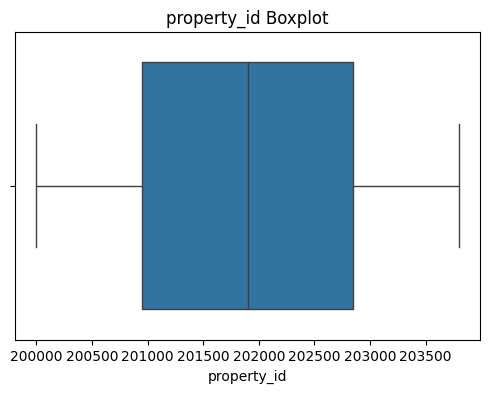

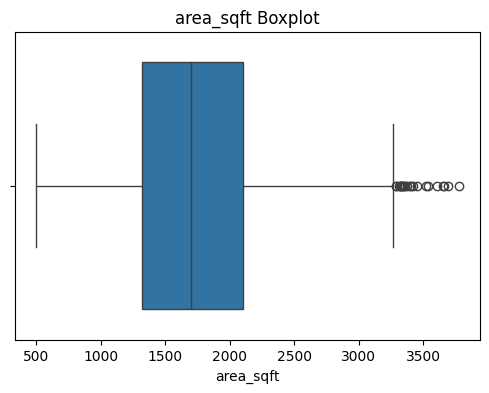

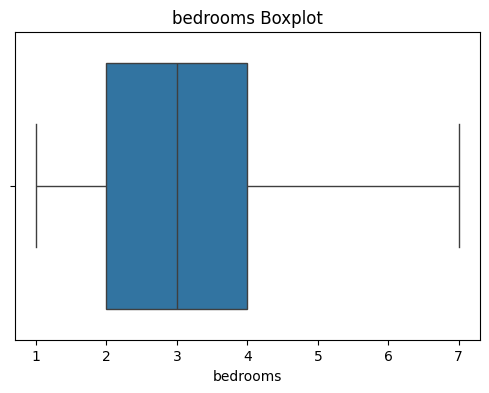

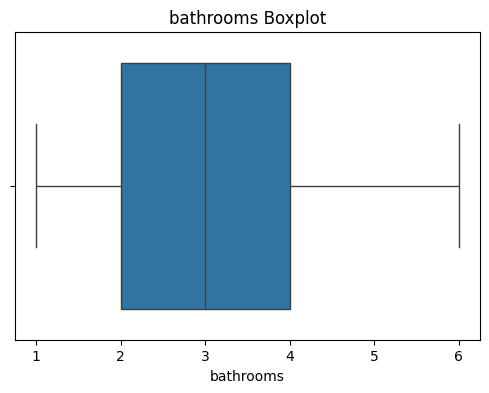

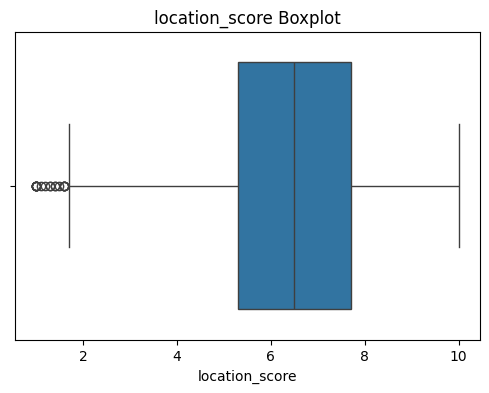

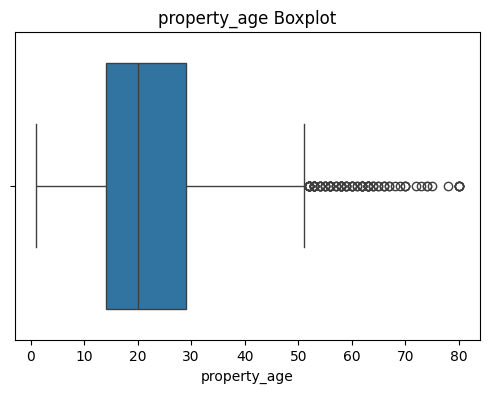

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols[:6]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')
    plt.show()

# HANDLE MISSING VALUES

In [14]:
numeric_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(exclude=np.number).columns

# Fill Numeric Missing Values
for col in numeric_features:
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Missing Values
for col in categorical_features:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Filling")
print(df.isnull().sum().sum())


Missing Values After Filling
0


# OUTLIER REMOVAL USING IQR

In [15]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Dataset Shape After Outlier Removal:", df.shape)

Dataset Shape After Outlier Removal: (3589, 12)


# LabelEncoding

In [16]:
le = LabelEncoder()

for col in categorical_features:
    df[col] = le.fit_transform(df[col].astype(str))

#  FEATURE ENGINEERING

In [17]:
if len(numeric_cols) >= 2:
    df['New_Feature_Sum'] = df[numeric_cols[0]] + df[numeric_cols[1]]

if len(numeric_cols) >= 3:
    df['New_Feature_Multiply'] = df[numeric_cols[1]] * df[numeric_cols[2]]


In [18]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr,New_Feature_Sum,New_Feature_Multiply
0,200001,48,2181,6,4,8.1,21,3.8,0,0,4.84,35154898,202182,13086
1,200002,119,2383,5,4,5.3,28,10.9,1,1,2.89,26710893,202385,11915
2,200003,81,1047,3,3,5.9,7,27.5,0,1,4.04,11216242,201050,3141
3,200004,38,1753,4,3,7.0,27,12.1,0,0,3.28,21984310,201757,7012
4,200005,42,1728,4,4,10.0,32,1.4,0,1,3.84,25080429,201733,6912


# Log Transformation

In [19]:
if df[target_column].min() > 0:
    df['Log_Target'] = np.log1p(df[target_column])


# FEATURE SCALING

In [20]:
X = df.drop(columns=[target_column])
y = df[target_column]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#  TRAIN TEST SPLIT

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (2871, 14)
Testing Shape: (718, 14)


# PART C – REGULARIZED LINEAR MODELS

RIDGE REGRESSION

In [23]:
ridge = Ridge()

ridge_params = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=5,
    scoring='r2'
)

ridge_grid.fit(X_train, y_train)

best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

print("\nRIDGE REGRESSION RESULTS")
print("Best Alpha:", ridge_grid.best_params_)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)
print("MAE:", ridge_mae)
print("R2 Score:", ridge_r2)


RIDGE REGRESSION RESULTS
Best Alpha: {'alpha': 0.1}
MSE: 3243826548223.4165
RMSE: 1801062.6164082738
MAE: 1270066.780622215
R2 Score: 0.9503318666561464


LASSO REGRESSION

In [24]:
lasso = Lasso()

lasso_params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=5,
    scoring='r2'
)

lasso_grid.fit(X_train, y_train)

best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test)

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print("\nLASSO REGRESSION RESULTS")
print("Best Alpha:", lasso_grid.best_params_)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)
print("MAE:", lasso_mae)
print("R2 Score:", lasso_r2)

C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.196e+14, tolerance: 1.500e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.517e+14, tolerance: 1.489e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi


LASSO REGRESSION RESULTS
Best Alpha: {'alpha': 10}
MSE: 3243569051046.8354
RMSE: 1800991.1301966025
MAE: 1269919.28304545
R2 Score: 0.9503358093466424


C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.417e+14, tolerance: 1.500e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.968e+14, tolerance: 1.489e+13
  model = cd_fast.enet_coordinate_descent(
C:\Users\red\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

# PART D – CROSS VALIDATION

 K-FOLD

In [25]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv = cross_val_score(best_ridge, X_scaled, y, cv=kfold, scoring='r2')

print("\nK-FOLD CV SCORES")
print(ridge_cv)
print("Average Score:", ridge_cv.mean())


K-FOLD CV SCORES
[0.95033187 0.95651503 0.94867541 0.95164766 0.95633067]
Average Score: 0.9527001286427887


# PART E – TREE BASED MODELS

DECISION TREE REGRESSOR

In [26]:
dt = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("\nDECISION TREE RESULTS")
print("MSE:", mean_squared_error(y_test, dt_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("R2:", r2_score(y_test, dt_pred))


DECISION TREE RESULTS
MSE: 1147431357.009568
RMSE: 33873.756169187494
MAE: 19163.894496748242
R2: 0.9999824310046189


 RANDOM FOREST REGRESSOR

In [27]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("\nRANDOM FOREST RESULTS")
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("R2:", r2_score(y_test, rf_pred))


RANDOM FOREST RESULTS
MSE: 344453162.8878502
RMSE: 18559.449423079615
MAE: 10618.354025069582
R2: 0.9999947258753294


# PART F – SUPPORT VECTOR REGRESSION

LINEAR SVR

In [28]:
svr_linear = SVR(
    kernel='linear',
    C=1
)

svr_linear.fit(X_train, y_train)

svr_linear_pred = svr_linear.predict(X_test)

print("\nLINEAR SVR RESULTS")
print("MSE:", mean_squared_error(y_test, svr_linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, svr_linear_pred)))
print("MAE:", mean_absolute_error(y_test, svr_linear_pred))
print("R2 Score:", r2_score(y_test, svr_linear_pred))


LINEAR SVR RESULTS
MSE: 65590689667570.49
RMSE: 8098807.916451069
MAE: 6496079.898953783
R2 Score: -0.004297570197896894


RBF SVR

In [29]:
svr_rbf = SVR(
    kernel='rbf',
    C=100,
    gamma=0.1,
    epsilon=0.1
)

svr_rbf.fit(X_train, y_train)

svr_rbf_pred = svr_rbf.predict(X_test)

print("\nRBF SVR RESULTS")
print("MSE:", mean_squared_error(y_test, svr_rbf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, svr_rbf_pred)))
print("MAE:", mean_absolute_error(y_test, svr_rbf_pred))
print("R2 Score:", r2_score(y_test, svr_rbf_pred))


RBF SVR RESULTS
MSE: 65575352763003.24
RMSE: 8097860.999239444
MAE: 6494224.414882922
R2 Score: -0.004062737844870545


# Part G – Model Comparison

Create Comparison Table

In [30]:
results = pd.DataFrame({
    'Model': [
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Random Forest',
        'SVR Linear',
        'SVR RBF'
    ],

    'R2 Score': [
        ridge_r2,
        lasso_r2,
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, svr_linear_pred),
        r2_score(y_test, svr_rbf_pred)
    ]
})

print("\nMODEL COMPARISON")
print(results)


MODEL COMPARISON
              Model  R2 Score
0  Ridge Regression  0.950332
1  Lasso Regression  0.950336
2     Decision Tree  0.999982
3     Random Forest  0.999995
4        SVR Linear -0.004298
5           SVR RBF -0.004063


BEST MODEL

In [31]:
best_model = results.loc[results['R2 Score'].idxmax()]

print("\nBEST MODEL")
print(best_model)


BEST MODEL
Model       Random Forest
R2 Score         0.999995
Name: 3, dtype: object


BAR GRAPH

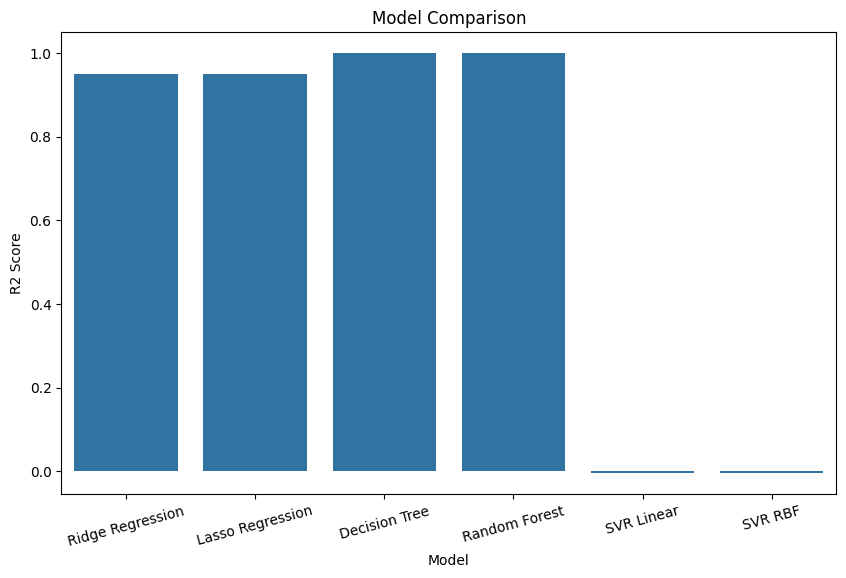

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title('Model Comparison')

plt.xticks(rotation=15)

plt.show()

# Part H – Final Analysis

OVERFITTING CHECK

In [33]:
train_score = rf.score(X_train, y_train)

test_score = rf.score(X_test, y_test)

print("\nOVERFITTING CHECK")

print("Training Score:", train_score)

print("Testing Score:", test_score)

if train_score > test_score + 0.15:
    print("Possible Overfitting Detected")

else:
    print("Model is Generalizing Well")


OVERFITTING CHECK
Training Score: 0.9999988681089572
Testing Score: 0.9999947258753294
Model is Generalizing Well
